In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import joblib
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("D:/Machine Learning datasets/Regression Models/Life Expectancy Data.csv")
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(2938, 22)
       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   
3  Afghanistan  2012  Developing              59.5            272.0   
4  Afghanistan  2011  Developing              59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   ...  \
0             62     0.01               71.279624         65.0      1154  ...   
1             64     0.01               73.523582         62.0       492  ...   
2             66     0.01               73.219243         64.0       430  ...   
3             69     0.01               78.184215         67.0      2787  ...   
4             71     0.01                7.097109         68.0      3013  ...   

   Polio  Total expenditure  Diphtheria    HIV/AIDS         GDP  Population

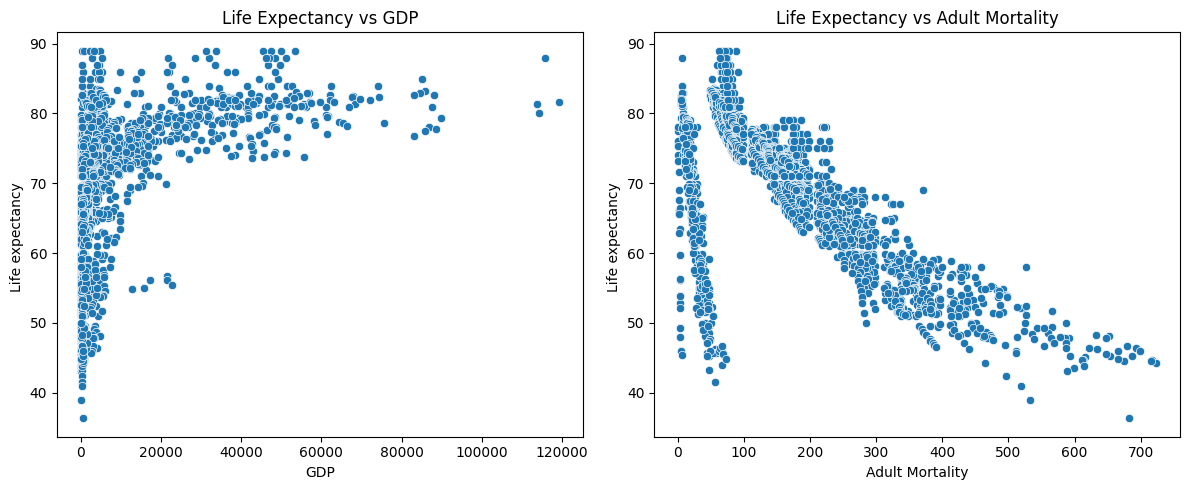

In [5]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x=df["GDP"], y=df["Life expectancy "])
plt.title("Life Expectancy vs GDP")

plt.subplot(1,2,2)
sns.scatterplot(x=df["Adult Mortality"], y=df["Life expectancy "])
plt.title("Life Expectancy vs Adult Mortality")

plt.tight_layout()
plt.show()

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

In [7]:
df["Status"].fillna(df["Status"].mode()[0], inplace=True)

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [8]:
le = LabelEncoder()
df["Status"] = le.fit_transform(df["Status"])

In [14]:
X = df.drop("Life expectancy ", axis=1)
y = df["Life expectancy "]
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
X = X[numeric_cols]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    results.append([name, mae, mse, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"]
)

print(results_df)

               Model       MAE        MSE      RMSE  R2 Score
0  Linear Regression  2.646404  12.205525  3.493641  0.859085
1      Decision Tree  1.475170   6.078605  2.465483  0.929822
2      Random Forest  1.107690   2.875511  1.695733  0.966802


<Figure size 1000x600 with 0 Axes>

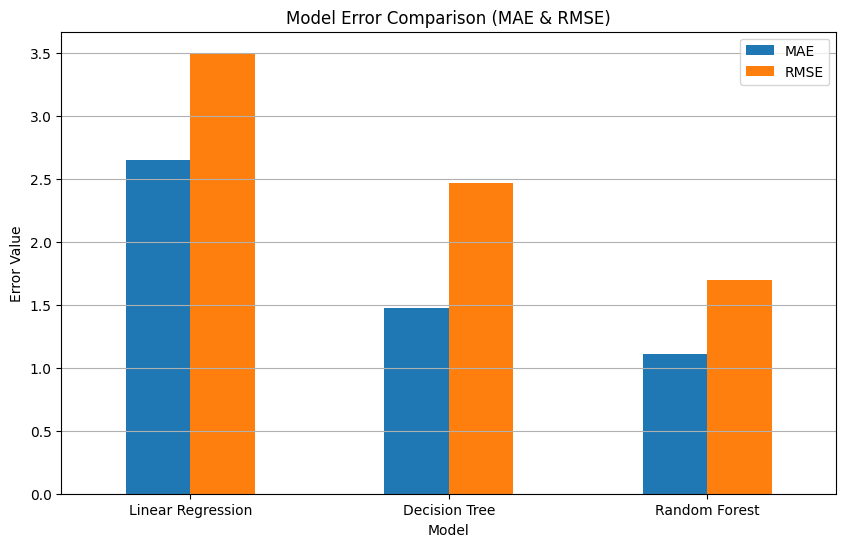

In [16]:
plt.figure(figsize=(10, 6))

results_df.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Error Comparison (MAE & RMSE)")
plt.ylabel("Error Value")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

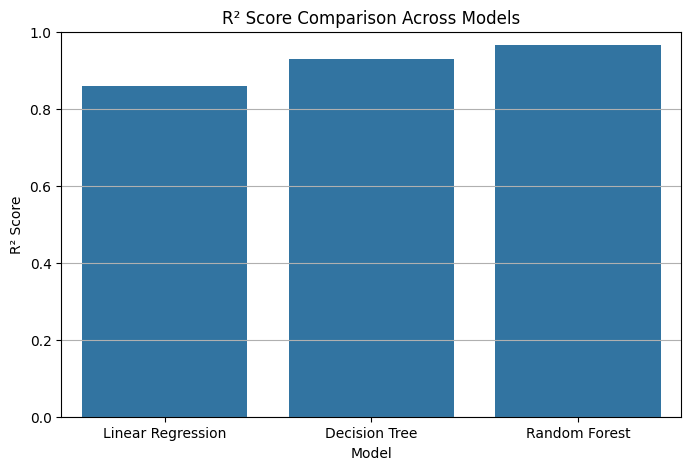

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=results_df
)

plt.title("R² Score Comparison Across Models")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.grid(axis="y")

plt.show()

In [18]:
for name, model in models.items():
    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    print(f"{name} → Train R2: {train_score:.3f}, Test R2: {test_score:.3f}")

Linear Regression → Train R2: 0.854, Test R2: 0.859
Decision Tree → Train R2: 1.000, Test R2: 0.930
Random Forest → Train R2: 0.995, Test R2: 0.967


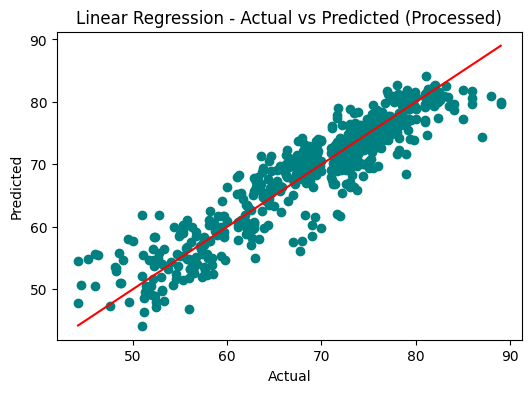

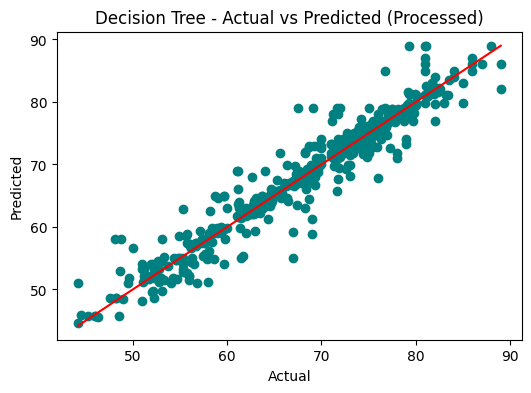

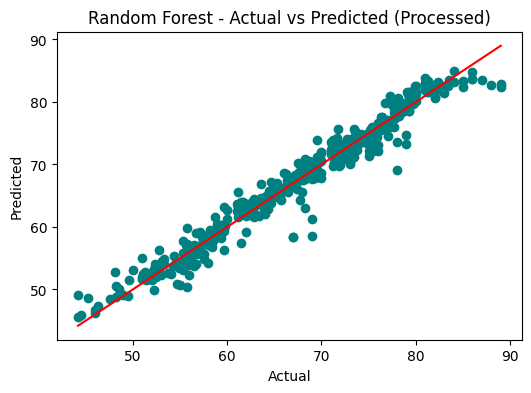

In [19]:
for name, model in models.items():
    preds = model.predict(X_test_scaled)
    
    plt.figure(figsize=(6,4))
    plt.scatter(y_test, preds, color="teal")
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color="red")
    plt.title(f"{name} - Actual vs Predicted (Processed)")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()


In [20]:
X_raw = X.copy()
y_raw = y.copy()

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

raw_results = []

for name, model in models.items():
    model.fit(Xr_train, yr_train)
    preds = model.predict(Xr_test)
    
    raw_results.append([
        name,
        mean_absolute_error(yr_test, preds),
        mean_squared_error(yr_test, preds),
        np.sqrt(mean_squared_error(yr_test, preds)),
        r2_score(yr_test, preds)
    ])


               Model       MAE        MSE      RMSE        R2
0  Linear Regression  2.646404  12.205525  3.493641  0.859085
1      Decision Tree  1.465306   5.943776  2.437986  0.931378
2      Random Forest  1.107395   2.862675  1.691944  0.966950


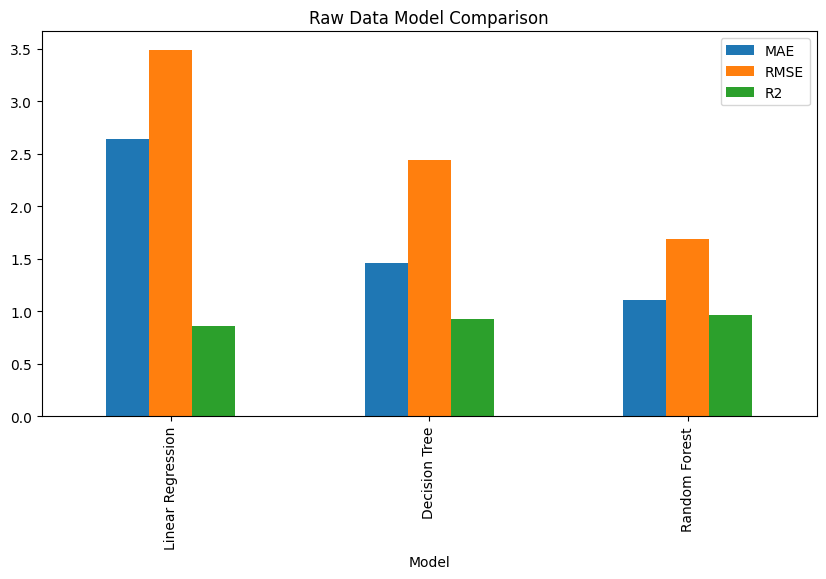

In [21]:
raw_df = pd.DataFrame(
    raw_results, columns=["Model","MAE","MSE","RMSE","R2"]
)
print(raw_df)

raw_df.set_index("Model")[["MAE","RMSE","R2"]].plot(
    kind="bar", figsize=(10,5), title="Raw Data Model Comparison"
)
plt.show()

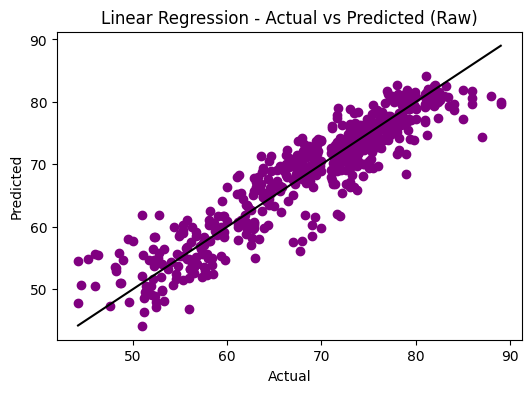

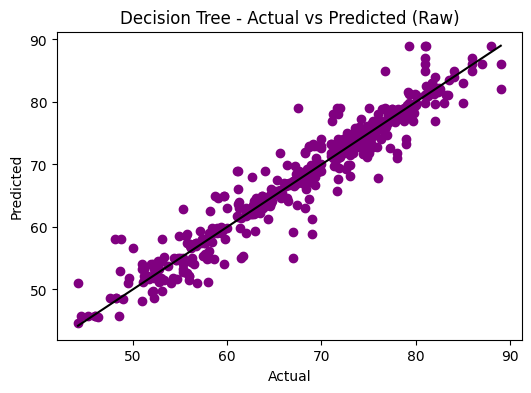

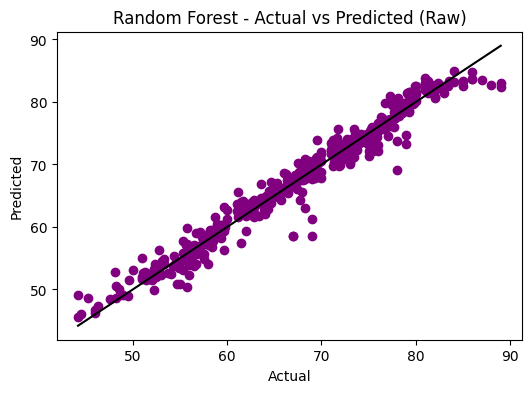

In [22]:
for name, model in models.items():
    preds = model.predict(Xr_test)
    
    plt.figure(figsize=(6,4))
    plt.scatter(yr_test, preds, color="purple")
    plt.plot([yr_test.min(), yr_test.max()],
             [yr_test.min(), yr_test.max()],
             color="black")
    plt.title(f"{name} - Actual vs Predicted (Raw)")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

In [2]:
joblib.dump(scaler, "scaler.pkl")

for name, model in models.items():
    joblib.dump(model, f"{name.replace(' ','_')}_processed.pkl")

df.to_csv("processed_life_expectancy.csv", index=False)

NameError: name 'joblib' is not defined